# Setting up

In [4]:
import glob
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# ── Step 1: load & inspect ────────────────────────────────────────────────────
df_fn = glob.glob("*recruitment_data*")
df = pd.read_csv(df_fn[0])

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# ── Step 2: define features — drop leaky HiringDecision ──────────────────────
FEATURES = [
    'Age', 'Gender', 'EducationLevel', 'ExperienceYears',
    'PreviousCompanies', 'DistanceFromCompany',
    'InterviewScore', 'SkillScore', 'PersonalityScore'
]
X = df[FEATURES].copy()

# ── Step 3: encode target ─────────────────────────────────────────────────────
strategy_map = {
    1: 0, 2: 1, 3: 2,
    'Aggressive': 0, 'Moderate': 1, 'Conservative': 2
}
y = df['RecruitmentStrategy'].map(strategy_map)
class_names = ['Aggressive', 'Moderate', 'Conservative']

assert y.isnull().sum() == 0, f"Unmapped values: {df['RecruitmentStrategy'][y.isnull()].unique()}"
assert set(y.unique()) == {0, 1, 2}

# ── Step 4: encode features ───────────────────────────────────────────────────
# Gender is already encoded: Male=0, Female=1 (per Kaggle description)
# No transformation needed — just document it
GENDER_MAP = {0: 'Male', 1: 'Female'}

# Only create label column for plots — never use for training
X['Gender_label'] = X['Gender'].map(GENDER_MAP)
X = X.drop(columns=['Gender_label'])  # drop after inspection

# EducationLevel is ordinal 1–4 — treat as numeric, no encoding needed
# All other features are already numeric

assert X.select_dtypes('object').empty, "String columns remain!"

# ── Step 5: check class balance ───────────────────────────────────────────────
counts = y.value_counts().sort_index()
pcts   = y.value_counts(normalize=True).sort_index() * 100
ratio  = counts.max() / counts.min()

print("\n=== Class distribution ===")
for i, name in enumerate(class_names):
    print(f"  {name:<15} {counts[i]:>4} rows  ({pcts[i]:.1f}%)")
print(f"\nImbalance ratio: {ratio:.2f}x")
print("→ Mild imbalance: use F1-macro + class_weight='balanced'")

# ── Step 6: split first, then scale ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts_s = y_split.value_counts().sort_index()
    pcts_s   = y_split.value_counts(normalize=True).sort_index() * 100
    print(f"\n{split_name}:")
    for i, name in enumerate(class_names):
        print(f"  {name:<15} {counts_s[i]:>4} rows  ({pcts_s[i]:.1f}%)")

# ── Step 7: scale ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only
X_test_s  = scaler.transform(X_test)       # apply train stats to test

# ── Step 8: verify ────────────────────────────────────────────────────────────
print("\n=== Check 1: train means (≈0) and stds (≈1) ===")
train_check = pd.DataFrame({
    'feature': X_train.columns,
    'mean':    X_train_s.mean(axis=0).round(3),
    'std':     X_train_s.std(axis=0).round(3),
})
print(train_check.to_string(index=False))

print("\n=== Check 2: test means (small offset fine) ===")
test_check = pd.DataFrame({
    'feature':        X_train.columns,
    'train_mean_was': scaler.mean_.round(3),
    'test_mean_now':  X_test_s.mean(axis=0).round(3),
})
print(test_check.to_string(index=False))

print("\n=== Check 3: NaN check ===")
assert np.isnan(X_train_s).sum() == 0, "NaNs in X_train_s!"
assert np.isnan(X_test_s).sum()  == 0, "NaNs in X_test_s!"
print("All checks passed. Ready for feature engineering.")

(1500, 11)
Age                      int64
Gender                   int64
EducationLevel           int64
ExperienceYears          int64
PreviousCompanies        int64
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy      int64
HiringDecision           int64
dtype: object
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

=== Class distribution ===
  Aggressive       445 rows  (29.7%)
  Moderate         770 rows  (51.3%)
  Conservative     285 rows  (19.0%)

Imbalance ratio: 2.70x
→ Mild imbalance: use F1-macro + class_weight='balanced'

Train: 1200 rows | Test: 300 rows

Train:
  Aggressive       356 rows  (29.7%)
  Moderate         616 rows  (51.3%)
  Conserv

In [5]:
def add_features(df):
    df = df.copy()

    # 1. Weighted composite quality score
    df['composite_score'] = (
        df['InterviewScore']  * 0.4 +
        df['SkillScore']       * 0.4 +
        df['PersonalityScore'] * 0.2
    )
    # 2. Senior candidate × distance interaction
    df['distance_x_exp'] = (
        df['DistanceFromCompany'] * df['ExperienceYears']
    )
    return df

In [6]:
X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f"Total features: {X_train.shape[1]}")
# → 11 features (9 original + 2 engineered)

assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum()  == 0
print("Done. Re-run scaling next.")

Total features: 11
Done. Re-run scaling next.


In [18]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Scaled shape: {X_train_s.shape}")
# → (1200, 11)

Scaled shape: (1200, 11)


In [21]:
X_train.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,composite_score,distance_x_exp
86,37,1,2,8,3,40.150012,96,96,83,93.4,321.200093
185,50,0,2,8,4,21.151566,97,38,14,56.8,169.212525
943,47,1,4,15,5,41.026805,73,26,84,56.4,615.402079
537,34,1,4,11,3,14.255663,75,65,85,73.0,156.812288
798,39,0,3,9,3,34.944367,65,86,17,63.8,314.499302


# Training models

In [10]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [13]:

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            probability=True,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            random_state=42
        ))
    ]),
}

In [14]:
models

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'Random Forest': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf',
                  RandomForestClassifier(class_weight='balanced',
                                         n_estimators=300, n_jobs=-1,
                                         random_state=42))]),
 'SVM': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf',
                  SVC(class_weight='balanced', probability=True,
                      random_state=42))]),
 'Gradient Boosting': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf',
                  GradientBoostingClassifier(learning_rate=0.05, max_depth=4,
                                             n_estimators=200,
                                             random_state=42))

In [15]:
# ── Cross-validate all models ─────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== 5-fold CV results (F1-macro) ===\n")
for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    results[name] = scores
    print(f"{name:<22} mean={scores.mean():.4f}  std={scores.std():.4f}  "
          f"per-fold={np.round(scores, 3)}")

=== 5-fold CV results (F1-macro) ===

Logistic Regression    mean=0.3338  std=0.0180  per-fold=[0.368 0.325 0.332 0.331 0.314]
Random Forest          mean=0.2933  std=0.0227  per-fold=[0.314 0.291 0.26  0.323 0.28 ]
SVM                    mean=0.3383  std=0.0314  per-fold=[0.363 0.33  0.288 0.331 0.38 ]
Gradient Boosting      mean=0.3027  std=0.0215  per-fold=[0.3   0.291 0.311 0.338 0.273]


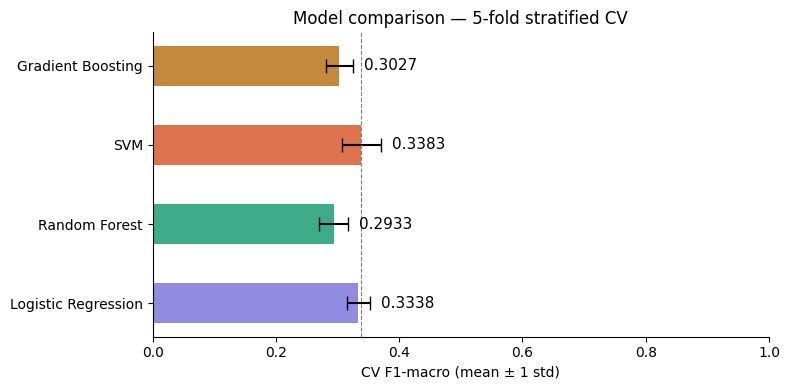

In [16]:
names  = list(results.keys())
means  = [r.mean() for r in results.values()]
stds   = [r.std()  for r in results.values()]
colors = ['#7F77DD', '#1D9E75', '#D85A30', '#BA7517']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, means, xerr=stds, color=colors,
               alpha=0.85, capsize=5, height=0.5)
ax.bar_label(bars, labels=[f'{m:.4f}' for m in means],
             padding=8, fontsize=11)
ax.set_xlabel('CV F1-macro (mean ± 1 std)')
ax.set_xlim(0, 1)
ax.axvline(x=max(means), color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Model comparison — 5-fold stratified CV')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Cause 1 - RecruitmentStrategy may not be predictable from candidate features alone

The strategy might be driven by business context, budget, urgency, or hiring manager preference — none of which are in the dataset. Run this quick check:

In [22]:
# If the target is essentially random w.r.t. features,
# no model will beat chance. Check raw correlation with target.
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("=== Feature correlations with target ===")
print(correlations.round(4))

=== Feature correlations with target ===
ExperienceYears        0.0503
SkillScore             0.0361
distance_x_exp         0.0308
composite_score        0.0301
EducationLevel         0.0269
PersonalityScore       0.0131
Gender                 0.0106
Age                    0.0089
PreviousCompanies      0.0040
DistanceFromCompany    0.0032
InterviewScore         0.0013
dtype: float64


In [25]:
# Check if HiringDecision has real signal — we expect it to be much higher
hiring_corr = X_train.corrwith(y_train.rename('strategy')).abs()

# Now check the same features against HiringDecision
temp = df.copy()
temp['Gender'] = temp['Gender']  # already 0/1
hiring = temp.loc[X_train.index, 'HiringDecision']

hiring_correlations = X_train.corrwith(hiring).abs().sort_values(ascending=False)
print("=== Feature correlations with HiringDecision ===")
print(hiring_correlations.round(4))

=== Feature correlations with HiringDecision ===
composite_score        0.3152
EducationLevel         0.2322
SkillScore             0.2040
PersonalityScore       0.1931
InterviewScore         0.1648
ExperienceYears        0.1176
distance_x_exp         0.0758
PreviousCompanies      0.0640
DistanceFromCompany    0.0082
Age                    0.0073
Gender                 0.0001
dtype: float64


# Cause 2

Cause 2 — target encoding order might not reflect the natural ordering. Double check your actual mapping:

In [24]:
print("Target value counts:")
print(y_train.value_counts().sort_index())
print("\nMapping used:")
print("0=Aggressive, 1=Moderate, 2=Conservative")

# Verify the raw column too
print("\nRaw strategy counts:")
print(df['RecruitmentStrategy'].value_counts())

Target value counts:
RecruitmentStrategy
0    356
1    616
2    228
Name: count, dtype: int64

Mapping used:
0=Aggressive, 1=Moderate, 2=Conservative

Raw strategy counts:
RecruitmentStrategy
2    770
1    445
3    285
Name: count, dtype: int64
